In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, pickle

ROOT = '/content/drive/MyDrive/CW_Folder_UG'
sys.path.insert(0, f'{ROOT}/Code')
from utils import *

import joblib

MODELS_DIR = f'{ROOT}/Models'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(f'{ROOT}/Code/data_splits.pkl', 'rb') as f:
    d = pickle.load(f)
train_paths, train_labels = d['train_paths'], d['train_labels']
test_paths,  test_labels  = d['test_paths'],  d['test_labels']
y_all  = np.array(train_labels)
y_test = np.array(test_labels)
print(f'Train: {len(train_paths)}  Test: {len(test_paths)}')

Mounted at /content/drive
Train: 13300  Test: 850


In [2]:
import shutil, os

LOCAL_ROOT = '/tmp/CW_data'

if not os.path.exists(LOCAL_ROOT):
    print("Copying dataset to local SSD.")
    shutil.copytree(ROOT, LOCAL_ROOT)
    print("Done.")
else:
    print("Local copy already exists, skipping.")

# Remap paths from Drive to local SSD
def remap(paths, src=ROOT, dst=LOCAL_ROOT):
    return [p.replace(src, dst) for p in paths]

train_paths = remap(train_paths)
test_paths  = remap(test_paths)
print(f"Paths remapped to {LOCAL_ROOT}")

Copying dataset to local SSD.
Done.
Paths remapped to /tmp/CW_data


In [3]:
with open(f'{ROOT}/Code/track1_results.pkl', 'rb') as f:
    t1 = pickle.load(f)
t1_results = t1['results']
top2 = sorted(t1_results, key=lambda n: t1_results[n]['test_acc'], reverse=True)[:2]
print(f'Top-2 Track 1 classifiers: {top2}')
print(f'  {top2[0]}: {t1_results[top2[0]]["test_acc"]:.4f}')
print(f'  {top2[1]}: {t1_results[top2[1]]["test_acc"]:.4f}')

Top-2 Track 1 classifiers: ['HOG+LBP+MLP', 'HOG+MLP']
  HOG+LBP+MLP: 0.7506
  HOG+MLP: 0.7482


In [4]:
N_CODEWORDS    = 200
MAX_KP_PER_IMG = 100

def extract_keypoint_descriptors(paths, detector, label=''):
    """Extract local descriptors for all images."""
    all_desc = []
    for i, p in enumerate(paths):
        if i % 500 == 0:
            print(f'  {label}: {i}/{len(paths)}')
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            all_desc.append(None); continue
        img = cv2.resize(img, IMAGE_SIZE)
        kp, des = detector.detectAndCompute(img, None)
        if des is None or len(des) == 0:
            all_desc.append(None)
        else:
            if len(des) > MAX_KP_PER_IMG:
                idx = np.random.choice(len(des), MAX_KP_PER_IMG, replace=False)
                des = des[idx]
            all_desc.append(des.astype(np.float32))
    return all_desc

def build_codebook(all_desc, n_words=N_CODEWORDS):
    """Build visual codebook via K-Means."""
    stacked = np.vstack([d for d in all_desc if d is not None])
    print(f'  K-Means: {stacked.shape[0]} descriptors → {n_words} codewords...')
    kmeans = MiniBatchKMeans(n_clusters=n_words, random_state=SEED,
                             batch_size=10000, n_init=3)
    kmeans.fit(stacked)
    return kmeans

def encode_bovw(all_desc, kmeans, n_words=N_CODEWORDS):
    """Encode each image as a normalised histogram of codewords."""
    histograms = []
    for des in all_desc:
        if des is None:
            histograms.append(np.zeros(n_words))
        else:
            word_labels = kmeans.predict(des)
            hist, _ = np.histogram(word_labels, bins=n_words,
                                   range=(0, n_words), density=True)
            histograms.append(hist)
    return np.array(histograms)

In [5]:
FEAT_PATH = f'{ROOT}/Code/features_track2.npz'

if os.path.exists(FEAT_PATH):
    print('Loading saved BoVW features...')
    data = np.load(FEAT_PATH)
    X_sift_all  = data['X_sift_all'];  X_sift_test = data['X_sift_test']
    X_surf_all  = data['X_surf_all'];  X_surf_test = data['X_surf_test']
    sift_kmeans = joblib.load(f'{MODELS_DIR}/sift_kmeans.pkl')
    surf_kmeans = joblib.load(f'{MODELS_DIR}/surf_kmeans.pkl')
else:
    sift = cv2.SIFT_create(nfeatures=MAX_KP_PER_IMG)

    print('Extracting SIFT descriptors (train)...')
    sift_desc_train = extract_keypoint_descriptors(train_paths, sift, 'SIFT-train')
    print('Extracting SIFT descriptors (test)...')
    sift_desc_test  = extract_keypoint_descriptors(test_paths,  sift, 'SIFT-test')

    print('Building SIFT codebook...')
    sift_kmeans = build_codebook(sift_desc_train)
    joblib.dump(sift_kmeans, f'{MODELS_DIR}/sift_kmeans.pkl')

    print('Encoding SIFT BoVW histograms...')
    X_sift_all  = encode_bovw(sift_desc_train, sift_kmeans)
    X_sift_test = encode_bovw(sift_desc_test,  sift_kmeans)

    # SURF (requires opencv-contrib; falls back to SIFT if unavailable)
    try:
        # !pip install opencv-contrib-python-headless -q
        import importlib; importlib.reload(cv2)
        surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
        SURF_AVAILABLE = True
        print('SURF available ✓')
    except Exception as e:
        print(f'SURF not available ({e}); using SIFT as proxy for SURF rows.')
        surf = sift
        SURF_AVAILABLE = False

    print('Extracting SURF descriptors (train)...')
    surf_desc_train = extract_keypoint_descriptors(train_paths, surf, 'SURF-train')
    print('Extracting SURF descriptors (test)...')
    surf_desc_test  = extract_keypoint_descriptors(test_paths,  surf, 'SURF-test')

    print('Building SURF codebook...')
    surf_kmeans = build_codebook(surf_desc_train)
    joblib.dump(surf_kmeans, f'{MODELS_DIR}/surf_kmeans.pkl')

    print('Encoding SURF BoVW histograms...')
    X_surf_all  = encode_bovw(surf_desc_train, surf_kmeans)
    X_surf_test = encode_bovw(surf_desc_test,  surf_kmeans)

    np.savez(FEAT_PATH,
             X_sift_all=X_sift_all, X_sift_test=X_sift_test,
             X_surf_all=X_surf_all, X_surf_test=X_surf_test)
    print('BoVW features saved.')

print(f'SIFT BoVW shape: {X_sift_all.shape}  SURF BoVW shape: {X_surf_all.shape}')

Extracting SIFT descriptors (train)...
  SIFT-train: 0/13300
  SIFT-train: 500/13300
  SIFT-train: 1000/13300
  SIFT-train: 1500/13300
  SIFT-train: 2000/13300
  SIFT-train: 2500/13300
  SIFT-train: 3000/13300
  SIFT-train: 3500/13300
  SIFT-train: 4000/13300
  SIFT-train: 4500/13300
  SIFT-train: 5000/13300
  SIFT-train: 5500/13300
  SIFT-train: 6000/13300
  SIFT-train: 6500/13300
  SIFT-train: 7000/13300
  SIFT-train: 7500/13300
  SIFT-train: 8000/13300
  SIFT-train: 8500/13300
  SIFT-train: 9000/13300
  SIFT-train: 9500/13300
  SIFT-train: 10000/13300
  SIFT-train: 10500/13300
  SIFT-train: 11000/13300
  SIFT-train: 11500/13300
  SIFT-train: 12000/13300
  SIFT-train: 12500/13300
  SIFT-train: 13000/13300
Extracting SIFT descriptors (test)...
  SIFT-test: 0/850
  SIFT-test: 500/850
Building SIFT codebook...
  K-Means: 909154 descriptors → 200 codewords...
Encoding SIFT BoVW histograms...
SURF not available (module 'cv2.xfeatures2d' has no attribute 'SURF_create'); using SIFT as proxy

In [6]:
(X_sift_tr, X_sift_val,
 X_surf_tr, X_surf_val,
 y_tr, y_val) = train_test_split(
    X_sift_all, X_surf_all, y_all,
    test_size=0.1, stratify=y_all, random_state=SEED
)

X_sift_tr_s, X_sift_val_s, X_sift_te_s, sc_sift = fit_scaler(X_sift_tr, X_sift_val, X_sift_test)
X_surf_tr_s, X_surf_val_s, X_surf_te_s, sc_surf = fit_scaler(X_surf_tr, X_surf_val, X_surf_test)
print(f'Train: {len(y_tr)}  Val: {len(y_val)}  Test: {len(y_test)}')

Train: 11970  Val: 1330  Test: 850


In [7]:
rbf_svm = lambda: svm.SVC(C=10, kernel='rbf', gamma='scale',
                           class_weight='balanced', random_state=SEED)
mlp     = lambda: MLPClassifier(hidden_layer_sizes=(512, 256), activation='relu',
                                 solver='adam', max_iter=100,
                                 early_stopping=True, random_state=SEED)

EXPERIMENTS = {
    'SIFT+BoVW+RBF-SVM': (rbf_svm(), X_sift_tr_s, X_sift_val_s, X_sift_te_s),
    'SIFT+BoVW+MLP':      (mlp(),    X_sift_tr_s, X_sift_val_s, X_sift_te_s),
    'SURF+BoVW+RBF-SVM':  (rbf_svm(), X_surf_tr_s, X_surf_val_s, X_surf_te_s),
    'SURF+BoVW+MLP':      (mlp(),    X_surf_tr_s, X_surf_val_s, X_surf_te_s),
}

In [8]:
results = {}

for name, (clf, Xtr, Xval, Xte) in EXPERIMENTS.items():
    print(f'\nTraining {name}...')
    t0 = time.time()
    clf.fit(Xtr, y_tr)
    tt = time.time() - t0

    val_pred  = clf.predict(Xval)
    test_pred = clf.predict(Xte)
    val_acc   = accuracy_score(y_val, val_pred)
    test_acc  = accuracy_score(y_test, test_pred)

    path = f'{MODELS_DIR}/track2_{name.replace("+", "_")}.pkl'
    joblib.dump(clf, path)

    results[name] = {
        'val_acc': val_acc, 'test_acc': test_acc,
        'train_time': tt, 'test_preds': test_pred, 'path': path
    }
    print(f'  val={val_acc:.4f}  test={test_acc:.4f}  time={tt:.1f}s')


Training SIFT+BoVW+RBF-SVM...
  val=0.5233  test=0.5412  time=52.8s

Training SIFT+BoVW+MLP...
  val=0.5075  test=0.5212  time=17.3s

Training SURF+BoVW+RBF-SVM...
  val=0.5195  test=0.5259  time=52.0s

Training SURF+BoVW+MLP...
  val=0.5008  test=0.5153  time=18.5s


In [9]:
print(f"{'Model':<22} {'Val Acc':>9} {'Test Acc':>10} {'Time(s)':>9}")
print('─' * 54)
for name, r in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{name:<22} {r['val_acc']:>9.4f} {r['test_acc']:>10.4f} {r['train_time']:>9.1f}")

best_name = max(results, key=lambda n: results[n]['test_acc'])
print(f"\nBest Track 2: {best_name}  (test acc={results[best_name]['test_acc']:.4f})")

Model                    Val Acc   Test Acc   Time(s)
──────────────────────────────────────────────────────
SIFT+BoVW+RBF-SVM         0.5233     0.5412      52.8
SURF+BoVW+RBF-SVM         0.5195     0.5259      52.0
SIFT+BoVW+MLP             0.5075     0.5212      17.3
SURF+BoVW+MLP             0.5008     0.5153      18.5

Best Track 2: SIFT+BoVW+RBF-SVM  (test acc=0.5412)


In [10]:
for name, r in results.items():
    evaluate(name, y_test, r['test_preds'], r['train_time'], r['path'])

Model: SIFT+BoVW+RBF-SVM
Training Time: 52.8 seconds
Model Size: 18.15 MB
Accuracy: 0.5412
Classification Report:
              precision    recall  f1-score   support

       Child       0.63      0.57      0.60       150
       Young       0.56      0.74      0.64       350
 Middle-Aged       0.41      0.29      0.34       200
      Senior       0.50      0.37      0.42       150

    accuracy                           0.54       850
   macro avg       0.53      0.49      0.50       850
weighted avg       0.53      0.54      0.53       850

Model: SIFT+BoVW+MLP
Training Time: 17.3 seconds
Model Size: 5.39 MB
Accuracy: 0.5212
Classification Report:
              precision    recall  f1-score   support

       Child       0.70      0.43      0.53       150
       Young       0.53      0.76      0.63       350
 Middle-Aged       0.41      0.27      0.32       200
      Senior       0.46      0.40      0.43       150

    accuracy                           0.52       850
   macro avg    

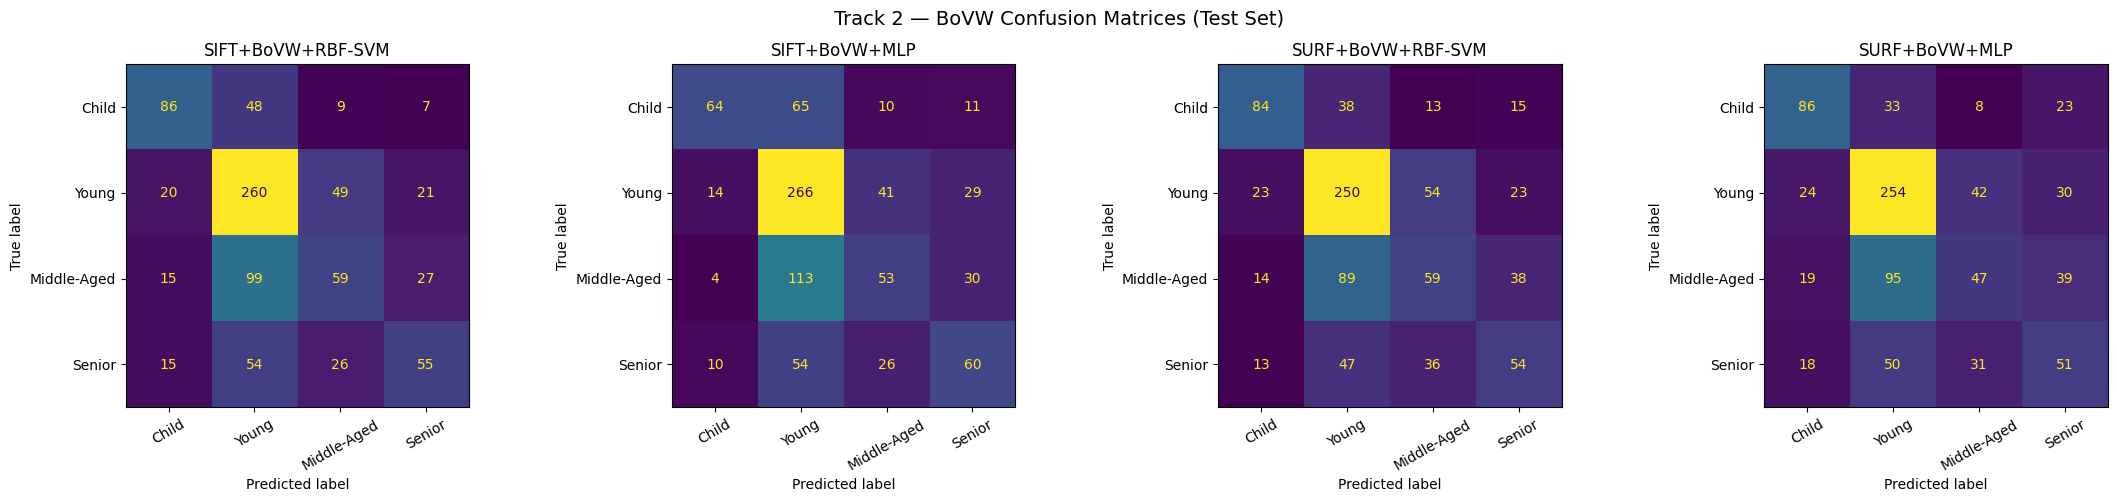

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes.flatten(), EXPERIMENTS.keys()):
    plot_confusion_matrix(name, y_test, results[name]['test_preds'], ax=ax)
plt.suptitle('Track 2 — BoVW Confusion Matrices (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

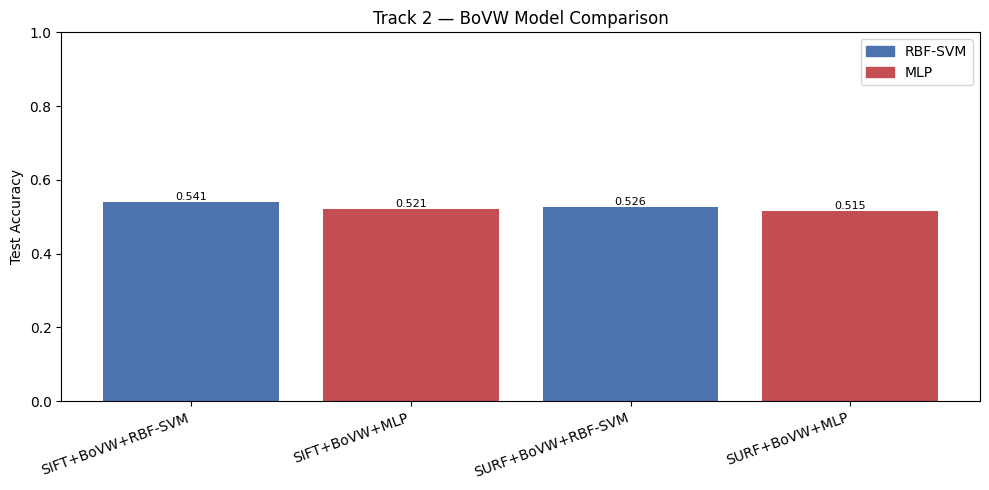

In [12]:
names = list(results.keys())
accs  = [results[n]['test_acc'] for n in names]
colors = ['#4C72B0', '#C44E52', '#4C72B0', '#C44E52']  # RBF-SVM, MLP per descriptor

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, accs, color=colors)
ax.set_ylim(0, 1); ax.set_ylabel('Test Accuracy')
ax.set_title('Track 2 — BoVW Model Comparison')
plt.xticks(rotation=20, ha='right')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{acc:.3f}',
            ha='center', fontsize=8)
handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(['#4C72B0', '#C44E52'], ['RBF-SVM', 'MLP'])]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

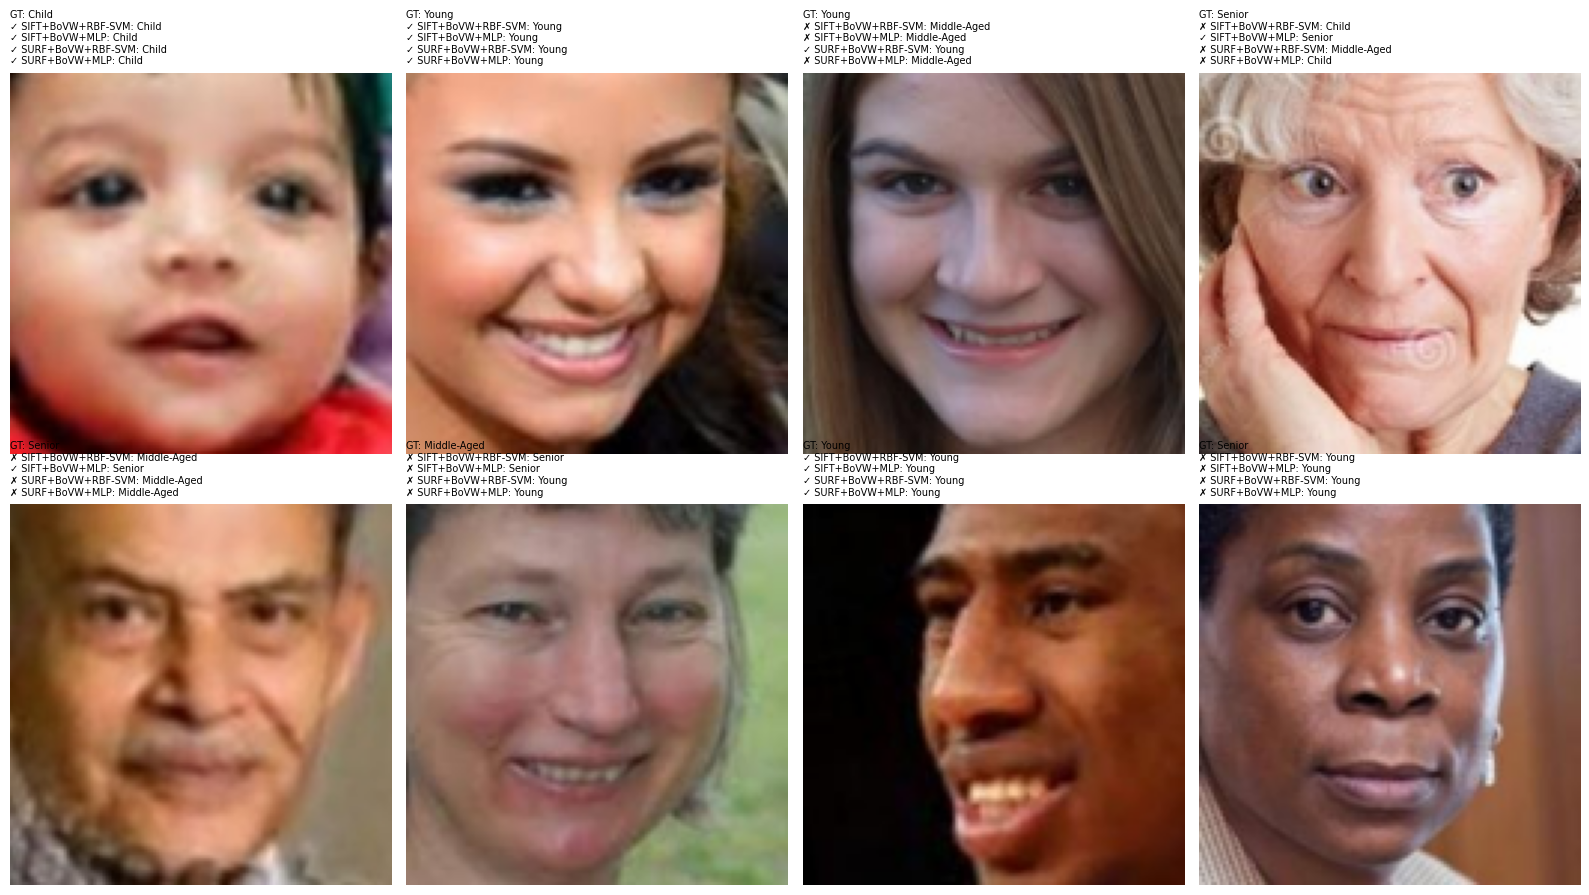

In [13]:
qualitative_grid(test_paths, test_labels,
                 {n: results[n]['test_preds'] for n in results}, n=8)

In [14]:
with open(f'{ROOT}/Code/track2_results.pkl', 'wb') as f:
    pickle.dump({
        'results':   results,
        'best_name': best_name,
        'scalers':   {'sift': sc_sift, 'surf': sc_surf}
    }, f)
print('Track 2 results saved')

Track 2 results saved
